## 1. Import Libraries and load the data 

## 2. Pre Processing 

- Descriptive
- Drop unnecessary columns
- Target from categoric to numeric conversion
- Check Missing Values

## 3. Pre processing steps for individual Model

- Logistic Regression ( target correlation 10% , intercorrelation 70% )
- KNN ( target correlation 10% , intercorrelation 70% )
- Random Forest
- Xgboost
- Catboost

## 4. Declare output and inputs for all models

## 5. Train and evaluate function

## 6. Hyperparameter optimization for given models

- Combine all models default and optimized result
- For the best tree based model check feature importance and shapley value. Drop not important features and train model again.

## 7. Train Voting Classifier both hard and soft and check results

## 8. Train Stacking Classifier (passthrough=True) with best models and check results

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

pd.set_option('display.max_columns',None)

from sklearn.model_selection import train_test_split

import optuna
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data=pd.read_excel(r'C:\Users\TOSHIBA\Downloads\telecom_churn.xlsx')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7795,7795,7795.000000,7795,7795,7709.000000,7795,7795,7795,7795,7599,7795,7795,7795,7795,7795,7795,7795,7795.000000,7784.000000,7795
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,9871-ELEYA,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,2,3928,NaN,4077,5500,NaN,7030,3740,3527,4039,3644,3563,4006,3219,3188,4433,4667,2718,NaN,NaN,5625
mean,NaN,NaN,0.165619,NaN,NaN,31.835387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.570186,2239.091656,NaN
std,NaN,NaN,0.371762,NaN,NaN,24.358809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.417788,2240.004669,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.400000,384.437500,NaN
50%,NaN,NaN,0.000000,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.750000,1378.350000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,54.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3673.600000,NaN


In [5]:
data=data.drop('customerID',axis=1)

In [6]:
print(data.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [7]:
data['Churn']=data['Churn'].map({'Yes':1,'No':0})
data


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.45,8058.85,0
7791,Male,1,No,No,15.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),74.20,1133.90,1
7792,Female,1,No,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,294.45,0
7793,Male,1,Yes,No,50.0,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),105.05,5163.30,0


In [8]:
data.isnull().sum()

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure               86
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup        196
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges         11
Churn                 0
dtype: int64

In [9]:
data_lr_knn_rf=data.copy()
data_xgb_cb_lgbm_cbc=data.copy()

In [10]:
data.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure              float64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [11]:
for i in data_lr_knn_rf.columns:
    if i in ['tenure','TotalCharges']:
        data_lr_knn_rf[i] = data_lr_knn_rf[i].fillna(data_lr_knn_rf[i].mean())
    else:
       data_lr_knn_rf[i] = data_lr_knn_rf[i].fillna(data_lr_knn_rf[i].mode()[0])
        
        

In [12]:
data_lr_knn_rf

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.45,8058.85,0
7791,Male,1,No,No,15.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),74.20,1133.90,1
7792,Female,1,No,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,294.45,0
7793,Male,1,Yes,No,50.0,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),105.05,5163.30,0


In [13]:
data_lr_knn_rf.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
data_lr=data_lr_knn_rf.copy()
data_knn=data_lr_knn_rf.copy()
data_rf=data_lr_knn_rf.copy()

### LR

In [15]:
for var in data_lr.columns:
    if var == 'Churn':
        continue  

    if data_lr[var].dtypes != 'str':
        
        q1 = data_lr[var].quantile(0.25)
        q2 = data_lr[var].quantile(0.5)
        q3 = data_lr[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        data_lr['category_' + var] = pd.cut(data_lr[var], bins=ranges, duplicates='drop')

        grouped = data_lr.groupby(['category_' + var, 'Churn'])['Churn'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[['category_' + var, var + '_woe']], how='left', on='category_' + var)

    elif data_lr[var].dtypes == 'str':

        grouped = data_lr.groupby([var, 'Churn'])['Churn'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[[var, var + '_woe']], how='left', on=var)
        
data_lr

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_woe,category_SeniorCitizen,SeniorCitizen_woe,Partner_woe,Dependents_woe,category_tenure,tenure_woe,PhoneService_woe,MultipleLines_woe,InternetService_woe,OnlineSecurity_woe,OnlineBackup_woe,DeviceProtection_woe,TechSupport_woe,StreamingTV_woe,StreamingMovies_woe,Contract_woe,PaperlessBilling_woe,PaymentMethod_woe,category_MonthlyCharges,MonthlyCharges_woe,category_TotalCharges,TotalCharges_woe
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,-0.017300,"(-inf, 0.0]",0.152689,0.393277,-0.225333,"(-inf, 9.0]",-0.951521,0.147862,0.147862,0.478622,-0.662789,0.340687,-0.552639,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,-0.813936,"(-inf, 43.4]",0.973049,"(-inf, 385.725]",-0.772430
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0.017162,"(-inf, 0.0]",0.152689,-0.306444,-0.225333,"(28.0, 54.0]",0.343138,-0.015499,0.067784,0.478622,0.805154,-0.544858,0.246202,-0.655778,-0.29824,-0.307431,1.103053,0.605651,0.444674,"(43.4, 70.75]",0.114972,"(1380.4, 3668.025]",0.224316
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.017162,"(-inf, 0.0]",0.152689,-0.306444,-0.225333,"(-inf, 9.0]",-0.951521,-0.015499,0.067784,0.478622,0.805154,0.340687,-0.552639,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,0.444674,"(43.4, 70.75]",0.114972,"(-inf, 385.725]",-0.772430
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0.017162,"(-inf, 0.0]",0.152689,-0.306444,-0.225333,"(28.0, 54.0]",0.343138,0.147862,0.147862,0.478622,0.805154,-0.544858,0.246202,0.749385,-0.29824,-0.307431,1.103053,0.605651,0.587710,"(-inf, 43.4]",0.973049,"(1380.4, 3668.025]",0.224316
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,-0.017300,"(-inf, 0.0]",0.152689,-0.306444,-0.225333,"(-inf, 9.0]",-0.951521,-0.015499,0.067784,-0.683806,-0.662789,-0.544858,-0.552639,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,-0.813936,"(43.4, 70.75]",0.114972,"(-inf, 385.725]",-0.772430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.45,8058.85,0,-0.017300,"(-inf, 0.0]",0.152689,0.393277,0.671129,"(54.0, inf]",1.457980,-0.015499,-0.106643,-0.683806,0.805154,-0.544858,0.246202,0.749385,-0.16842,-0.159784,2.548665,-0.326430,0.587710,"(89.85, inf]",-0.305296,"(3668.025, inf]",0.807893
7791,Male,1,No,No,15.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),74.20,1133.90,1,0.017162,"(0.0, inf]",-0.660744,-0.306444,-0.225333,"(9.0, 28.0]",-0.120361,-0.015499,-0.106643,-0.683806,-0.662789,-0.544858,-0.552639,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,0.711090,"(70.75, 89.85]",-0.492822,"(385.725, 1380.4]",0.011702
7792,Female,1,No,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,294.45,0,-0.017300,"(0.0, inf]",-0.660744,-0.306444,-0.225333,"(-inf, 9.0]",-0.951521,-0.015499,-0.106643,-0.683806,-0.662789,-0.544858,-0.552639,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,-0.813936,"(70.75, 89.85]",-0.492822,"(-inf, 385.725]",-0.772430
7793,Male,1,Yes,No,50.0,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),105.05,5163.30,0,0.017162,"(0.0, inf]",-0.660744,0.393277,-0.225333,"(28.0, 54.0]",0.343138,-0.015499,-0.106643,-0.683806,0.805154,-0.544858,0.246202,-0.655778,-0.16842,-0.159784,2.548665,-0.326430,0.711090,"(89.85, in

In [16]:
def target_correlation(data, target, threshold=0.1):
    
    woe_features = data.filter(regex='_woe$', axis=1) 
    woe_features[target] = data[target] 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target


target_result = target_correlation(data_lr, 'Churn')

target_result

,Variable,Correlation with Target
0,SeniorCitizen_woe,-0.148301
1,Partner_woe,-0.153024
2,Dependents_woe,-0.163836
3,tenure_woe,-0.338665
4,InternetService_woe,-0.326771
5,OnlineSecurity_woe,-0.346364
6,OnlineBackup_woe,-0.287405
7,DeviceProtection_woe,-0.279649
8,TechSupport_woe,-0.341434
9,StreamingTV_woe,-0.185708


In [17]:
def intercorrelation(data, target, threshold=0.7):
    
    woe_features = data.filter(regex='_woe$', axis=1) 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    correlated_pairs_set = set()
   
    for var1, var2 in zip(independent_variable_pairs[0], independent_variable_pairs[1]):

        if var1 < var2:
            correlated_pairs_set.add((corr_matrix.index[var1], corr_matrix.columns[var2]))
        else:
            correlated_pairs_set.add((corr_matrix.index[var2], corr_matrix.columns[var1]))
            
   # print(correlated_pairs_set)
    
    result_intercorrelated_independent = pd.DataFrame(list(correlated_pairs_set), columns=['Variable 1', 'Variable 2'])
    
    return result_intercorrelated_independent

# Example usage
intercorrelated_result = intercorrelation(data_lr, 'Churn')
intercorrelated_result


,Variable 1,Variable 2
0,InternetService_woe,MonthlyCharges_woe
1,StreamingTV_woe,StreamingMovies_woe
2,tenure_woe,TotalCharges_woe


In [18]:
target_result.Variable.tolist()

['SeniorCitizen_woe',
 'Partner_woe',
 'Dependents_woe',
 'tenure_woe',
 'InternetService_woe',
 'OnlineSecurity_woe',
 'OnlineBackup_woe',
 'DeviceProtection_woe',
 'TechSupport_woe',
 'StreamingTV_woe',
 'StreamingMovies_woe',
 'Contract_woe',
 'PaperlessBilling_woe',
 'PaymentMethod_woe',
 'MonthlyCharges_woe',
 'TotalCharges_woe']

In [19]:
LR_var=target_result.Variable.tolist()
LR_var

['SeniorCitizen_woe',
 'Partner_woe',
 'Dependents_woe',
 'tenure_woe',
 'InternetService_woe',
 'OnlineSecurity_woe',
 'OnlineBackup_woe',
 'DeviceProtection_woe',
 'TechSupport_woe',
 'StreamingTV_woe',
 'StreamingMovies_woe',
 'Contract_woe',
 'PaperlessBilling_woe',
 'PaymentMethod_woe',
 'MonthlyCharges_woe',
 'TotalCharges_woe']

### KNN

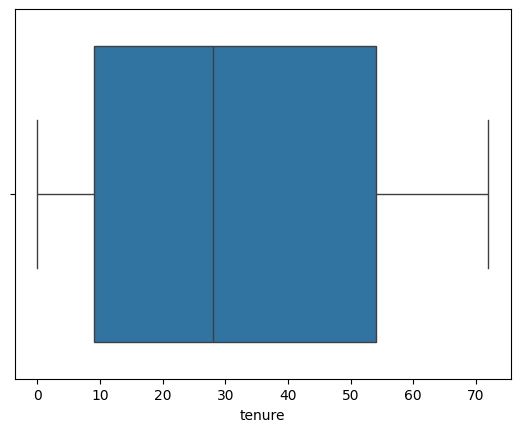

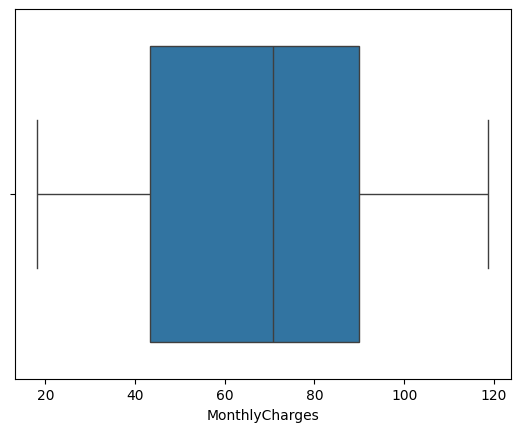

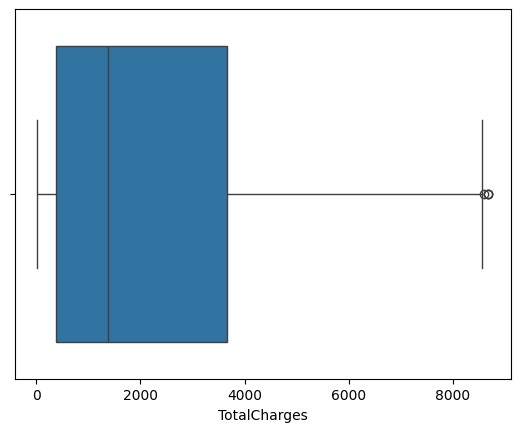

In [20]:
for i in data_knn.columns:
    if data_knn[i].dtypes!='str' and i not in ['Churn','SeniorCitizen']:
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [21]:
q1=data_knn.quantile(0.25,numeric_only=True)
q3=data_knn.quantile(0.75,numeric_only=True)
IQR=q3-q1
Lower=q1-1.5*IQR
Upper=q3+1.5*IQR

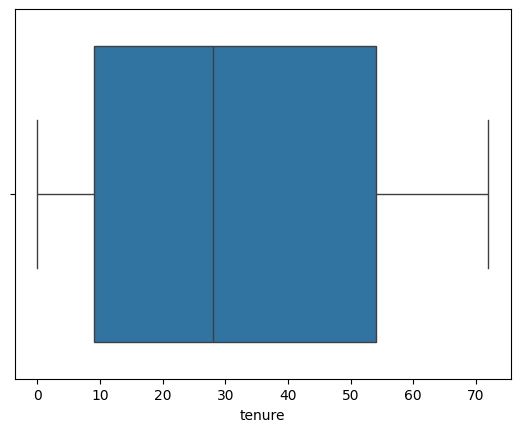

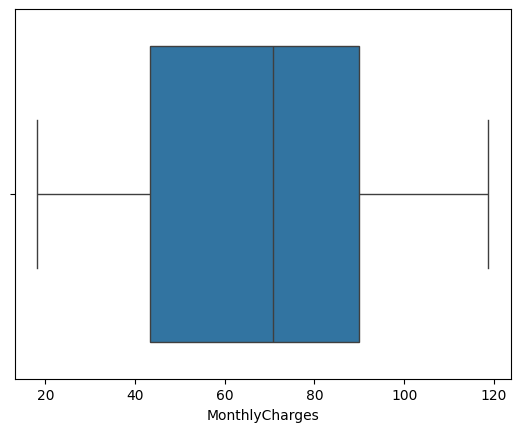

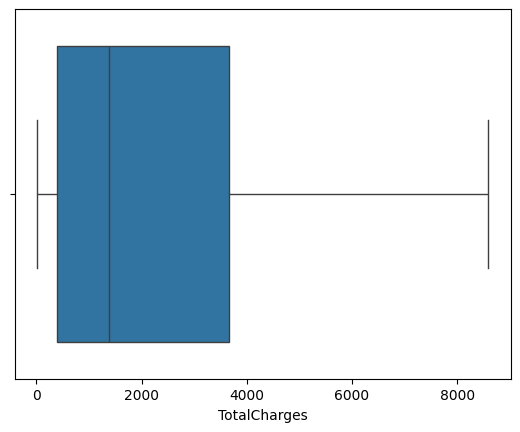

In [22]:
for i in data_knn.columns:
    if data_knn[i].dtypes!='str' and i not in ['Churn','SeniorCitizen']:
        data_knn[i]=np.where(data_knn[i]<Lower[i],Lower[i],data_knn[i])
        data_knn[i]=np.where(data_knn[i]>Upper[i],Upper[i],data_knn[i])
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()
    

In [23]:
def target_correlation(data, target, threshold=0.1):
    corr_matrix = data.corr(method='spearman', numeric_only=True)
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target

target_result = target_correlation(data_knn, 'Churn')

target_result

,Variable,Correlation with Target
0,SeniorCitizen,0.148301
1,tenure,-0.362228
2,MonthlyCharges,0.185910
3,TotalCharges,-0.243797


In [24]:
def intercorrelation(data, target, threshold=0.7):
    corr_matrix = data.drop(columns=[target]).corr(method='spearman', numeric_only=True)
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    result_intercorrelated_independent = pd.DataFrame({
        'Variable 1': corr_matrix.index[independent_variable_pairs[0]],
        'Variable 2': corr_matrix.columns[independent_variable_pairs[1]]
    })
    return result_intercorrelated_independent

intercorrelated_result = intercorrelation(data_knn, 'Churn')

intercorrelated_result

,Variable 1,Variable 2
0,tenure,TotalCharges
1,TotalCharges,tenure


In [25]:
target_result.Variable.tolist()

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, variables):
    vif_data = data_knn[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data_knn, ['SeniorCitizen', 'tenure', 'MonthlyCharges', #'TotalCharges'
   ])

vif_result


,VIF,Features
0,1.260143,SeniorCitizen
1,2.615829,tenure
2,2.935129,MonthlyCharges


In [27]:
vif_result.Features.tolist()


['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [28]:
data_knn.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in data_knn.columns:
    if data_knn[i].dtypes=='str':
        data_knn[i]=le.fit_transform(data_knn[i])

In [30]:
data_knn

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1.0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34.0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2.0,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45.0,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2.0,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,0,0,1,1,72.0,1,2,1,2,0,2,2,2,2,2,1,0,110.45,8058.85,0
7791,1,1,0,0,15.0,1,2,1,0,0,0,0,0,0,0,1,1,74.20,1133.90,1
7792,0,1,0,0,4.0,1,2,1,0,0,0,0,0,0,0,1,2,74.45,294.45,0
7793,1,1,1,0,50.0,1,2,1,2,0,2,0,2,2,2,1,1,105.05,5163.30,0


### RF

In [31]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in data_rf.columns:
    if data_rf[i].dtypes=='str':
        data_rf[i]=le.fit_transform(data_rf[i])
data_rf

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1.0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34.0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2.0,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45.0,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2.0,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,0,0,1,1,72.0,1,2,1,2,0,2,2,2,2,2,1,0,110.45,8058.85,0
7791,1,1,0,0,15.0,1,2,1,0,0,0,0,0,0,0,1,1,74.20,1133.90,1
7792,0,1,0,0,4.0,1,2,1,0,0,0,0,0,0,0,1,2,74.45,294.45,0
7793,1,1,1,0,50.0,1,2,1,2,0,2,0,2,2,2,1,1,105.05,5163.30,0


### XGBOOST LGBM CATBOOST

In [32]:
data_cbc = data_xgb_cb_lgbm_cbc.copy()
data_xgb_cb_lgbm=data_xgb_cb_lgbm_cbc.copy()


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for i in data_xgb_cb_lgbm.columns:
   data_xgb_cb_lgbm[i] = le.fit_transform(data_xgb_cb_lgbm[i])
data_xgb_cb_lgbm

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,142,74,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,498,3624,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,436,536,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,266,3570,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,729,674,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,0,0,1,1,72,1,2,1,2,0,2,2,2,2,2,1,0,1477,6462,0
7791,1,1,0,0,15,1,2,1,0,0,0,0,0,0,0,1,1,791,2675,1
7792,0,1,0,0,4,1,2,1,0,0,0,0,0,0,0,1,2,796,1120,0
7793,1,1,1,0,50,1,2,1,2,0,2,0,2,2,2,1,1,1376,5469,0


In [34]:
data_cbc.isnull().sum()

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure               86
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup        196
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges         11
Churn                 0
dtype: int64

In [35]:
for i in data_cbc.columns:
    if data_cbc[i].dtypes=='str':
        data_cbc[i]=data_cbc[i].fillna('Missing Value')
        
data_cbc.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure              86
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [36]:
output = data['Churn']

In [37]:
inputs_lr = data_lr[LR_var]
inputs_knn = data_knn[[ 'SeniorCitizen', 'tenure', 'MonthlyCharges','PhoneService','MultipleLines', 'InternetService','gender','StreamingTV',
'StreamingMovies',
 'Partner',
 'Dependents',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod'
 ]]
      
inputs_rf = data_rf.drop('Churn', axis=1)
inputs_xgb_cb_lgbm = data_xgb_cb_lgbm.drop('Churn', axis=1)
inputs_cbc = data_cbc.drop('Churn', axis=1)

In [38]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(inputs_knn)
inputs_scaled=scaler.transform(inputs_knn)
inputs_knn_scaled = pd.DataFrame(inputs_scaled, columns=inputs_knn.columns)

inputs_knn_scaled

,SeniorCitizen,tenure,MonthlyCharges,PhoneService,MultipleLines,InternetService,gender,StreamingTV,StreamingMovies,Partner,Dependents,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod
0,-0.445526,-1.273006,-1.214316,-3.031426,0.060902,-1.166841,-1.007856,-1.091231,-1.099910,1.047166,-0.645967,-0.886505,1.344609,-1.000036,-0.893984,-0.799119,0.818681,0.399628
1,-0.445526,0.089364,-0.293045,0.329878,-0.994054,-1.166841,0.992205,-1.091231,-1.099910,-0.954958,-0.645967,1.422317,-0.932434,1.247090,-0.893984,0.413246,-1.221478,1.345318
2,-0.445526,-1.231722,-0.398430,0.329878,-0.994054,-1.166841,0.992205,-1.091231,-1.099910,-0.954958,-0.645967,1.422317,1.344609,-1.000036,-0.893984,-0.799119,0.818681,1.345318
3,-0.445526,0.543487,-0.791075,-3.031426,0.060902,-1.166841,0.992205,-1.091231,-1.099910,-0.954958,-0.645967,1.422317,-0.932434,1.247090,1.408926,0.413246,-1.221478,-1.491752
4,-0.445526,-1.231722,0.174389,0.329878,-0.994054,0.215668,-1.007856,-1.091231,-1.099910,-0.954958,-0.645967,-0.886505,-0.932434,-1.000036,-0.893984,-0.799119,0.818681,0.399628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,-0.445526,1.658154,1.525699,0.329878,1.115858,0.215668,-1.007856,1.139596,1.130526,1.047166,1.548068,1.422317,-0.932434,1.247090,1.408926,1.625611,0.818681,-1.491752
7791,2.244539,-0.695031,0.293372,0.329878,1.115858,0.215668,0.992205,-1.091231,-1.099910,-0.954958,-0.645967,-0.886505,-0.932434,-1.000036,-0.893984,-0.799119,0.818681,-0.546062
7792,2.244539,-1.149154,0.301871,0.329878,1.115858,0.215668,-1.007856,-1.091231,-1.099910,-0.954958,-0.645967,-0.886505,-0.932434,-1.000036,-0.893984,-0.799119,0.818681,0.399628
7793,2.244539,0.749907,1.342125,0.329878,1.115858,0.215668,0.992205,1.139596,1.130526,1.047166,-0.645967,1.422317,-0.932434,1.247090,-0.893984,1.625611,0.818681,-0.546062


In [39]:
X_train_lr, X_test_lr, y_train, y_test = train_test_split(inputs_lr, output, test_size=0.3, random_state=42)
X_train_knn, X_test_knn, y_train, y_test = train_test_split(inputs_knn_scaled, output, test_size=0.3, random_state=42)
X_train_rf, X_test_rf, y_train, y_test = train_test_split(inputs_rf, output, test_size=0.3, random_state=42)
X_train_xgb_cb_lgbm, X_test_xgb_cb_lgbm, y_train, y_test = train_test_split(inputs_xgb_cb_lgbm, output, test_size=0.3, random_state=42)
X_train_cbc, X_test_cbc, y_train, y_test = train_test_split(inputs_cbc, output, test_size=0.3, random_state=42)

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_prob_train = model.predict_proba(X_train)[:, 1]

        roc_prob_train = roc_auc_score(y_train, y_prob_train)
        gini_prob_train = roc_prob_train * 2 - 1
        confusion_matrix_result_train = confusion_matrix(y_train, y_pred_train)
        classification_report_result_train = classification_report(y_train, y_pred_train)

        print(f'Model Performance for {model_name}')
        print('Train Gini prob is', gini_prob_train * 100)
        print(classification_report_result_train)
        print(confusion_matrix_result_train)

        y_pred_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1]

        roc_prob_test = roc_auc_score(y_test, y_prob_test)
        gini_prob_test = roc_prob_test * 2 - 1
        confusion_matrix_result_test = confusion_matrix(y_test, y_pred_test)
        classification_report_result_test = classification_report(y_test, y_pred_test)

        print(f'Model Performance for {model_name}')
        print('Test Gini prob is', gini_prob_test * 100)
        print(classification_report_result_test)
        print(confusion_matrix_result_test)

        return [gini_prob_train, gini_prob_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [41]:
for i in data.columns:
    if data[i].dtypes=='str':
        print(i)

gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod


In [42]:
models = []

lr_model = LogisticRegression()
knn_model_def = KNeighborsClassifier()
rf_model_def = RandomForestClassifier(random_state=42)
xgb_model_def = XGBClassifier(random_state=42)
lgbm_model_def=LGBMClassifier(random_state=42)
catboost_model_def = CatBoostClassifier(random_state=42)
catboost_model_custom = CatBoostClassifier(cat_features=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling',
'PaymentMethod'], random_state=42)

models.extend([
    ('LogReg', lr_model),
    ('KNN', knn_model_def),
    ('RF', rf_model_def),
    ('XGBoost', xgb_model_def),
    ('LGBM',lgbm_model_def),
    ('CatBoost', catboost_model_def),
    ('CatBoost_Custom', catboost_model_custom)
])

In [43]:
gini_df = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models:
    if model_name == 'LogReg':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_lr, y_train, X_test_lr, y_test)
    elif model_name == 'KNN':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_knn, y_train, X_test_knn, y_test)
    elif model_name == 'RF':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_rf, y_train, X_test_rf, y_test)
    elif model_name == 'CatBoost_Custom':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_cbc, y_train, X_test_cbc, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_cb_lgbm, y_train, X_test_xgb_cb_lgbm, y_test)

    if gini_prob is not None:
        gini_df = pd.concat([gini_df, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted = gini_df.sort_values(by='Test Gini', ascending=False)

gini_df_sorted

Model Performance for LogReg
Train Gini prob is 68.24021758832171
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      3964
           1       0.66      0.53      0.58      1492

    accuracy                           0.79      5456
   macro avg       0.74      0.71      0.72      5456
weighted avg       0.79      0.79      0.79      5456

[[3552  412]
 [ 708  784]]
Model Performance for LogReg
Test Gini prob is 69.60852740024043
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1661
           1       0.68      0.54      0.60       678

    accuracy                           0.79      2339
   macro avg       0.75      0.72      0.73      2339
weighted avg       0.78      0.79      0.78      2339

[[1487  174]
 [ 314  364]]
Model Performance for KNN
Train Gini prob is 78.20129827969149
              precision    recall  f1-score   support

           0       0.87      0.90      0.88

,Model,Train Gini,Test Gini
2,RF,0.999939,0.729975
6,CatBoost_Custom,0.795106,0.719214
4,LGBM,0.918447,0.717651
5,CatBoost,0.893494,0.717515
3,XGBoost,0.980774,0.70642
0,LogReg,0.682402,0.696085
1,KNN,0.782013,0.559818


In [44]:
gini_df_sorted

,Model,Train Gini,Test Gini
2,RF,0.999939,0.729975
6,CatBoost_Custom,0.795106,0.719214
4,LGBM,0.918447,0.717651
5,CatBoost,0.893494,0.717515
3,XGBoost,0.980774,0.70642
0,LogReg,0.682402,0.696085
1,KNN,0.782013,0.559818


### HYPERPARAMETER

In [45]:
# KNN

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_neighbors': trial.suggest_int('n_neighbors', 1, 50), 
    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),  
    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),  
    'leaf_size': trial.suggest_int('leaf_size', 10, 100),  
    'p': trial.suggest_int('p', 1, 2),  
    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan']) 
}

    knn_clf = KNeighborsClassifier(**param)

    roc = cross_val_score(knn_clf, X_train_knn, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsClassifier(**best_params)

[I 2026-04-07 12:07:16,408] A new study created in memory with name: no-name-91f8afdc-2db3-4ac8-bcbc-1f69ca1814fa
[I 2026-04-07 12:07:24,863] Trial 0 finished with value: 0.7698476812158968 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 83, 'p': 1, 'metric': 'minkowski'}. Best is trial 0 with value: 0.7698476812158968.
[I 2026-04-07 12:07:25,312] Trial 1 finished with value: 0.8393206463461091 and parameters: {'n_neighbors': 40, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 21, 'p': 1, 'metric': 'manhattan'}. Best is trial 1 with value: 0.8393206463461091.
[I 2026-04-07 12:07:25,740] Trial 2 finished with value: 0.7582514926468035 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'algorithm': 'kd_tree', 'leaf_size': 91, 'p': 2, 'metric': 'manhattan'}. Best is trial 1 with value: 0.8393206463461091.
[I 2026-04-07 12:07:26,275] Trial 3 finished with value: 0.8176536853561363 and parameters: {'n_neighbors': 26, 'weights': 'uni

Best trial:
  Value: 0.843
  Params:  {'n_neighbors': 50, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 14, 'p': 1, 'metric': 'manhattan'}


In [46]:
# RF

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
    'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt']),  
    'max_depth': trial.suggest_int('max_depth', 10, 50),  
    'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),  
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),  
}

    rf_clf = RandomForestClassifier(**param)

    roc = cross_val_score(rf_clf, X_train_rf, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model = RandomForestClassifier(**best_params)

[I 2026-04-07 12:07:58,328] A new study created in memory with name: no-name-7893de3a-f09a-452c-929f-a47b831709a4
[I 2026-04-07 12:07:58,947] Trial 0 finished with value: 0.8429112679408896 and parameters: {'n_estimators': 26, 'max_features': 'log2', 'max_depth': 31, 'min_samples_split': 129, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8429112679408896.
[I 2026-04-07 12:07:59,521] Trial 1 finished with value: 0.8425748889908448 and parameters: {'n_estimators': 38, 'max_features': 'log2', 'max_depth': 30, 'min_samples_split': 125, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.8429112679408896.
[I 2026-04-07 12:08:00,265] Trial 2 finished with value: 0.8425836663464814 and parameters: {'n_estimators': 53, 'max_features': 'sqrt', 'max_depth': 11, 'min_samples_split': 200, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.8429112679408896.
[I 2026-04-07 12:08:00,937] Trial 3 finished with value: 0.8419981656936052 and parameters: {'n_estimators': 47, 'max_features':

Best trial:
  Value: 0.850
  Params:  {'n_estimators': 233, 'max_features': 'log2', 'max_depth': 33, 'min_samples_split': 19, 'min_samples_leaf': 8}


In [47]:
# XGBoost

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train_xgb_cb_lgbm, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model = XGBClassifier(**best_params)

[I 2026-04-07 12:10:59,295] A new study created in memory with name: no-name-d819901a-a38e-4699-96fd-c8e2b9bb8b75
[I 2026-04-07 12:11:00,149] Trial 0 finished with value: 0.8407760333392779 and parameters: {'n_estimators': 543, 'learning_rate': 0.3520922196777996, 'max_depth': 5, 'subsample': 0.9641306542728334, 'colsample_bytree': 0.700792268446778, 'gamma': 10}. Best is trial 0 with value: 0.8407760333392779.
[I 2026-04-07 12:11:01,451] Trial 1 finished with value: 0.844280054972426 and parameters: {'n_estimators': 887, 'learning_rate': 0.01311399959153901, 'max_depth': 4, 'subsample': 0.5226728976836912, 'colsample_bytree': 0.8777383620371388, 'gamma': 10}. Best is trial 1 with value: 0.844280054972426.
[I 2026-04-07 12:11:01,734] Trial 2 finished with value: 0.8458873141394537 and parameters: {'n_estimators': 67, 'learning_rate': 0.04553101160273363, 'max_depth': 6, 'subsample': 0.5206934061719903, 'colsample_bytree': 0.9075828059602875, 'gamma': 5}. Best is trial 2 with value: 0.8

Best trial:
  Value: 0.846
  Params:  {'n_estimators': 67, 'learning_rate': 0.04553101160273363, 'max_depth': 6, 'subsample': 0.5206934061719903, 'colsample_bytree': 0.9075828059602875, 'gamma': 5}


In [48]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), 
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss'])
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train_xgb_cb_lgbm, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=1)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model = CatBoostClassifier(**best_params)

[I 2026-04-07 12:11:16,735] A new study created in memory with name: no-name-5e30a79e-1c2d-42b4-8c92-26d651a24726
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\3786495622.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\3786495622.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
[I 2026-04-07 12:11:33,648] Trial 0 finished with value: 0.8412394181525388 and parameters: {'iterations': 389, 'learning_rate': 0.03648531317899597, 'depth': 10, 'l2_leaf_reg': 0.4115798667997739, 

Best trial:
  Value: 0.841
  Params:  {'iterations': 389, 'learning_rate': 0.03648531317899597, 'depth': 10, 'l2_leaf_reg': 0.4115798667997739, 'loss_function': 'Logloss'}


In [49]:
from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train_xgb_cb_lgbm, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model = LGBMClassifier(**best_params)

[I 2026-04-07 12:11:35,759] A new study created in memory with name: no-name-7d906885-d813-48c6-bfd1-bd80170dc2a3
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\824024768.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-07 12:11:43,112] Trial 0 finished with value: 0.834288195206614 and parameters: {'n_estimators': 772, 'learning_rate': 0.04224557573393839, 'max_depth': 6, 'num_leaves': 59}. Best is trial 0 with value: 0.834288195206614.
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\824024768.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_l

Best trial:
  Value: 0.840
  Params:  {'n_estimators': 135, 'learning_rate': 0.03382053351504914, 'max_depth': 9, 'num_leaves': 98}


In [50]:
models_optimized = []

models_optimized.extend([
    ('KNN Optuna', best_knn_model),
    ('RF Optuna', best_rf_model),
    ('XGBoost Optuna', best_xgb_model),
    ('CatBoost Optuna', best_cb_model),
    ('LGBM Optuna',best_lgb_model)
])

In [51]:
gini_df_optuna = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models_optimized:
    if model_name == 'KNN Optuna':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_knn, y_train, X_test_knn, y_test)
    elif model_name == 'RF Optuna':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_rf, y_train, X_test_rf, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_cb_lgbm, y_train, X_test_xgb_cb_lgbm, y_test)

    if gini_prob is not None:
        gini_df_optuna = pd.concat([gini_df_optuna, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted_optuna = gini_df_optuna.sort_values(by='Test Gini', ascending=False)

gini_df_sorted_optuna


Model Performance for KNN Optuna
Train Gini prob is 99.99827536298535
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3964
           1       1.00      0.99      1.00      1492

    accuracy                           1.00      5456
   macro avg       1.00      1.00      1.00      5456
weighted avg       1.00      1.00      1.00      5456

[[3963    1]
 [   9 1483]]
Model Performance for KNN Optuna
Test Gini prob is 73.30854107505344
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1661
           1       0.68      0.63      0.65       678

    accuracy                           0.81      2339
   macro avg       0.77      0.75      0.76      2339
weighted avg       0.80      0.81      0.80      2339

[[1462  199]
 [ 254  424]]
Model Performance for RF Optuna
Train Gini prob is 83.61244836233878
              precision    recall  f1-score   support

           0       0.86      

,Model,Train Gini,Test Gini
0,KNN Optuna,0.999983,0.733085
1,RF Optuna,0.836124,0.7185
2,XGBoost Optuna,0.740155,0.71745
3,CatBoost Optuna,0.997774,0.710247
4,LGBM Optuna,0.92305,0.709921


In [52]:
final_review = pd.concat([gini_df_sorted,gini_df_sorted_optuna], axis=0)

final_review_sorted = final_review.sort_values(by='Test Gini', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted['Gini_gap'] = (final_review_sorted['Train Gini'] - final_review_sorted['Test Gini']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Test Gini', 'Gini_gap'],
    ascending=[False, True]
).reset_index(drop=True)

final_review_sorted

,Model,Train Gini,Test Gini,Gini_gap
0,KNN Optuna,0.999983,0.733085,0.266897
1,RF,0.999939,0.729975,0.269964
2,CatBoost_Custom,0.795106,0.719214,0.075892
3,RF Optuna,0.836124,0.7185,0.117625
4,LGBM,0.918447,0.717651,0.200796
5,CatBoost,0.893494,0.717515,0.175979
6,XGBoost Optuna,0.740155,0.71745,0.022705
7,CatBoost Optuna,0.997774,0.710247,0.287528
8,LGBM Optuna,0.92305,0.709921,0.213129
9,XGBoost,0.980774,0.70642,0.274354


In [56]:
variables = []
train_gini_scores = []
test_gini_scores = []


for i in X_train_lr.columns:
    X_train_single_var = X_train_lr[[i]]
    X_test_single_var = X_test_lr[[i]]

    
    lr_model.fit(X_train_single_var, y_train)
    
    y_pred_train_single_var = lr_model.predict_proba(X_train_single_var)[:, 1]

    train_roc = roc_auc_score(y_train, y_pred_train_single_var)
    train_gini = 2 * train_roc - 1

    
    y_pred_test_single_var = lr_model.predict_proba(X_test_single_var)[:, 1]

    test_roc = roc_auc_score(y_test, y_pred_test_single_var)
    test_gini = 2 * test_roc - 1


    variables.append(i)
    train_gini_scores.append(train_gini)
    test_gini_scores.append(test_gini)


results_df = pd.DataFrame({
                            'Variable': variables,
                            'Train Gini': train_gini_scores,
                            'Test Gini': test_gini_scores
                        })

results_df_sorted = results_df.sort_values(by='Test Gini', ascending=False)

pd.options.display.float_format = '{:.4f}'.format

results_df_sorted


,Variable,Train Gini,Test Gini
11,Contract_woe,0.4616,0.4851
5,OnlineSecurity_woe,0.4033,0.4134
4,InternetService_woe,0.3793,0.4128
8,TechSupport_woe,0.3982,0.4079
3,tenure_woe,0.4308,0.4031
13,PaymentMethod_woe,0.3348,0.3616
7,DeviceProtection_woe,0.3222,0.3575
6,OnlineBackup_woe,0.3454,0.3261
14,MonthlyCharges_woe,0.2557,0.3023
15,TotalCharges_woe,0.3051,0.2889


In [58]:
filtered_df = results_df_sorted[
    (results_df_sorted['Test Gini'] > 0.10) &
    (abs(results_df_sorted['Train Gini'] - results_df_sorted['Test Gini']) <= 0.05)
]

filtered_df


,Variable,Train Gini,Test Gini
11,Contract_woe,0.4616,0.4851
5,OnlineSecurity_woe,0.4033,0.4134
4,InternetService_woe,0.3793,0.4128
8,TechSupport_woe,0.3982,0.4079
3,tenure_woe,0.4308,0.4031
13,PaymentMethod_woe,0.3348,0.3616
7,DeviceProtection_woe,0.3222,0.3575
6,OnlineBackup_woe,0.3454,0.3261
14,MonthlyCharges_woe,0.2557,0.3023
15,TotalCharges_woe,0.3051,0.2889


In [59]:
filtered_df.Variable.tolist()

['Contract_woe',
 'OnlineSecurity_woe',
 'InternetService_woe',
 'TechSupport_woe',
 'tenure_woe',
 'PaymentMethod_woe',
 'DeviceProtection_woe',
 'OnlineBackup_woe',
 'MonthlyCharges_woe',
 'TotalCharges_woe',
 'StreamingMovies_woe',
 'PaperlessBilling_woe',
 'StreamingTV_woe',
 'Partner_woe',
 'Dependents_woe',
 'SeniorCitizen_woe']

In [77]:
inputs_uni = data_lr[['Contract_woe',
 'OnlineSecurity_woe',
 'InternetService_woe',
 'TechSupport_woe',
 'tenure_woe',
 'PaymentMethod_woe',
 'DeviceProtection_woe',
 'OnlineBackup_woe',
 'MonthlyCharges_woe',
 'TotalCharges_woe',
 'StreamingMovies_woe',
 'PaperlessBilling_woe',
 'StreamingTV_woe',
 'Partner_woe',
 'Dependents_woe',
 'SeniorCitizen_woe']]

output= data_lr['Churn']

In [78]:
X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(inputs_uni, output, test_size=0.2, random_state=42)

In [79]:
lr_uni = LogisticRegression()
lr_uni.fit(X_train_uni, y_train_uni)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [80]:
result_uni = train_and_evaluate_model('lr_uni',lr_uni, X_train_uni, y_train_uni, X_test_uni, y_test_uni)

result_uni

Model Performance for lr_uni
Train Gini prob is 68.8311577085123
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      4496
           1       0.66      0.54      0.59      1740

    accuracy                           0.79      6236
   macro avg       0.75      0.72      0.73      6236
weighted avg       0.78      0.79      0.79      6236

[[4012  484]
 [ 804  936]]
Model Performance for lr_uni
Test Gini prob is 68.26765814571448
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1129
           1       0.63      0.54      0.58       430

    accuracy                           0.79      1559
   macro avg       0.73      0.71      0.72      1559
weighted avg       0.78      0.79      0.78      1559

[[993 136]
 [198 232]]


[0.6883115770851229, 0.6826765814571447]

### Voting

In [81]:
inputs_vot = data_knn[['SeniorCitizen', 'tenure', 'MonthlyCharges','PhoneService','MultipleLines', 'InternetService','gender','StreamingTV',
'StreamingMovies',
 'Partner',
 'Dependents',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']]

X_train, X_test, y_train, y_test = train_test_split(inputs_vot, output, test_size=0.3, random_state=42)

In [97]:
lr_vot = LogisticRegression(max_iter=1000)
lr_vot.fit(X_train_uni, y_train_uni)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [84]:
# RF

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
    'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt']),  
    'max_depth': trial.suggest_int('max_depth', 10, 50),  
    'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),  
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),  
}

    rf_clf = RandomForestClassifier(**param)

    roc = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model_vot = RandomForestClassifier(**best_params)

[I 2026-04-07 12:46:36,030] A new study created in memory with name: no-name-efdc2e90-7a3b-4422-a353-9ae8649ee5c5
[I 2026-04-07 12:46:44,662] Trial 0 finished with value: 0.8374322894103964 and parameters: {'n_estimators': 14, 'max_features': 'log2', 'max_depth': 42, 'min_samples_split': 196, 'min_samples_leaf': 22}. Best is trial 0 with value: 0.8374322894103964.
[I 2026-04-07 12:46:45,722] Trial 1 finished with value: 0.8394986307435284 and parameters: {'n_estimators': 84, 'max_features': 'sqrt', 'max_depth': 28, 'min_samples_split': 156, 'min_samples_leaf': 34}. Best is trial 1 with value: 0.8394986307435284.
[I 2026-04-07 12:46:50,698] Trial 2 finished with value: 0.8451126621005699 and parameters: {'n_estimators': 358, 'max_features': 'log2', 'max_depth': 39, 'min_samples_split': 26, 'min_samples_leaf': 13}. Best is trial 2 with value: 0.8451126621005699.
[I 2026-04-07 12:46:53,651] Trial 3 finished with value: 0.841997379546752 and parameters: {'n_estimators': 227, 'max_features'

Best trial:
  Value: 0.847
  Params:  {'n_estimators': 418, 'max_features': 'sqrt', 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 7}


In [85]:
# XGBoost

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model_vot = XGBClassifier(**best_params)

[I 2026-04-07 12:50:16,673] A new study created in memory with name: no-name-957ba580-74c1-4765-9a6e-43386468f5ae
[I 2026-04-07 12:50:17,685] Trial 0 finished with value: 0.8434266871557888 and parameters: {'n_estimators': 604, 'learning_rate': 0.012906715413452159, 'max_depth': 3, 'subsample': 0.7167385385500651, 'colsample_bytree': 0.642590097526893, 'gamma': 9}. Best is trial 0 with value: 0.8434266871557888.
[I 2026-04-07 12:50:17,932] Trial 1 finished with value: 0.840985580705102 and parameters: {'n_estimators': 67, 'learning_rate': 0.2041587646710455, 'max_depth': 8, 'subsample': 0.8406311001850275, 'colsample_bytree': 0.8735335877600525, 'gamma': 2}. Best is trial 0 with value: 0.8434266871557888.
[I 2026-04-07 12:50:18,916] Trial 2 finished with value: 0.8449900202946473 and parameters: {'n_estimators': 755, 'learning_rate': 0.0482204824644886, 'max_depth': 9, 'subsample': 0.8989332291790421, 'colsample_bytree': 0.7274068890275023, 'gamma': 7}. Best is trial 2 with value: 0.84

Best trial:
  Value: 0.845
  Params:  {'n_estimators': 372, 'learning_rate': 0.043082794235790964, 'max_depth': 3, 'subsample': 0.8305255916653089, 'colsample_bytree': 0.5439391959783595, 'gamma': 3}


In [86]:
# Catboost

def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), 
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss'])
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=1)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model_vot = CatBoostClassifier(**best_params)

[I 2026-04-07 12:50:42,789] A new study created in memory with name: no-name-22e4a34d-b461-493f-a440-a1650722caa4
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\4118186931.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\4118186931.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
[I 2026-04-07 12:50:47,253] Trial 0 finished with value: 0.8432256954522951 and parameters: {'iterations': 426, 'learning_rate': 0.03254296296553909, 'depth': 7, 'l2_leaf_reg': 1.377842866590102, 'l

Best trial:
  Value: 0.843
  Params:  {'iterations': 426, 'learning_rate': 0.03254296296553909, 'depth': 7, 'l2_leaf_reg': 1.377842866590102, 'loss_function': 'Logloss'}


In [87]:


def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgbm_model_vot = LGBMClassifier(**best_params)

[I 2026-04-07 12:50:54,253] A new study created in memory with name: no-name-caaadd2e-bb3c-40b6-a0ff-b8e6d7e152c0
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\3599205400.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-07 12:50:58,633] Trial 0 finished with value: 0.8393729452267159 and parameters: {'n_estimators': 304, 'learning_rate': 0.03657051961987092, 'max_depth': 5, 'num_leaves': 15}. Best is trial 0 with value: 0.8393729452267159.
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_12744\3599205400.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.sugge

Best trial:
  Value: 0.839
  Params:  {'n_estimators': 304, 'learning_rate': 0.03657051961987092, 'max_depth': 5, 'num_leaves': 15}


In [98]:
voting_clf_hard = VotingClassifier(
    estimators=[
        ('lr', lr_vot),
        ('rf', best_rf_model_vot),
        ('xgb', best_xgb_model_vot),
        ('cat', best_cb_model_vot),
        ('lgbm',best_lgbm_model_vot)
    ],
    voting='hard' 
)

In [99]:
from sklearn.metrics import classification_report

def train_and_evaluate_model_voting_hard(model_name, model, X_train, y_train, X_test, y_test):
    try:
        print(f"\nTraining {model_name}...")
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Classification reports as dicts
        train_report_dict = classification_report(y_train, y_train_pred, output_dict=True)
        test_report_dict = classification_report(y_test, y_test_pred, output_dict=True)

        # Convert to DataFrames
        train_report_df = pd.DataFrame(train_report_dict).transpose()
        test_report_df = pd.DataFrame(test_report_dict).transpose()

        # Add model info
        train_report_df["Dataset"] = "Train"
        train_report_df["Model"] = model_name

        test_report_df["Dataset"] = "Test"
        test_report_df["Model"] = model_name

        # Combine into one dataframe
        final_df = pd.concat([train_report_df, test_report_df], axis=0)

        return final_df

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [100]:
train_and_evaluate_model_voting_hard('Voting model', voting_clf_hard, X_train, y_train, X_test, y_test)


Training Voting model...
0:	learn: 0.6704756	total: 8.18ms	remaining: 3.48s
1:	learn: 0.6489578	total: 16.3ms	remaining: 3.46s
2:	learn: 0.6303861	total: 23.7ms	remaining: 3.34s
3:	learn: 0.6171212	total: 28.5ms	remaining: 3.01s
4:	learn: 0.6014866	total: 35.8ms	remaining: 3.01s
5:	learn: 0.5870340	total: 44ms	remaining: 3.08s
6:	learn: 0.5738454	total: 51.6ms	remaining: 3.09s
7:	learn: 0.5647849	total: 56ms	remaining: 2.93s
8:	learn: 0.5537263	total: 63.7ms	remaining: 2.95s
9:	learn: 0.5434539	total: 71.6ms	remaining: 2.98s
10:	learn: 0.5340880	total: 79.9ms	remaining: 3.01s
11:	learn: 0.5253302	total: 88ms	remaining: 3.04s
12:	learn: 0.5168803	total: 96.3ms	remaining: 3.06s
13:	learn: 0.5088488	total: 104ms	remaining: 3.07s
14:	learn: 0.5023538	total: 112ms	remaining: 3.07s
15:	learn: 0.4953992	total: 120ms	remaining: 3.08s
16:	learn: 0.4895011	total: 128ms	remaining: 3.08s
17:	learn: 0.4842723	total: 136ms	remaining: 3.09s
18:	learn: 0.4807625	total: 142ms	remaining: 3.04s
19:	lear

,precision,recall,f1-score,support,Dataset,Model
0,0.8606,0.9253,0.8918,3964.0000,Train,Voting model
1,0.7521,0.6019,0.6687,1492.0000,Train,Voting model
accuracy,0.8369,0.8369,0.8369,0.8369,Train,Voting model
macro avg,0.8064,0.7636,0.7802,5456.0000,Train,Voting model
weighted avg,0.8309,0.8369,0.8308,5456.0000,Train,Voting model
0,0.8373,0.9109,0.8725,1661.0000,Test,Voting model
1,0.7218,0.5664,0.6347,678.0000,Test,Voting model
accuracy,0.8110,0.8110,0.8110,0.8110,Test,Voting model
macro avg,0.7796,0.7386,0.7536,2339.0000,Test,Voting model
weighted avg,0.8038,0.8110,0.8036,2339.0000,Test,Voting model


In [101]:
voting_clf_soft = VotingClassifier(
    estimators=[
        ('lr', lr_vot),
        ('rf', best_rf_model_vot),
        ('xgb', best_xgb_model_vot),
        ('cat', best_cb_model_vot),
        ('lgbm',best_lgbm_model_vot)
    ],
    voting='soft' 
)

train_and_evaluate_model('Voting model', voting_clf_soft, X_train, y_train, X_test, y_test)

0:	learn: 0.6704756	total: 7.83ms	remaining: 3.33s
1:	learn: 0.6489578	total: 15.8ms	remaining: 3.36s
2:	learn: 0.6303861	total: 23.4ms	remaining: 3.3s
3:	learn: 0.6171212	total: 27.8ms	remaining: 2.93s
4:	learn: 0.6014866	total: 35.4ms	remaining: 2.98s
5:	learn: 0.5870340	total: 42.9ms	remaining: 3s
6:	learn: 0.5738454	total: 50.6ms	remaining: 3.03s
7:	learn: 0.5647849	total: 54.9ms	remaining: 2.87s
8:	learn: 0.5537263	total: 62.5ms	remaining: 2.89s
9:	learn: 0.5434539	total: 70ms	remaining: 2.91s
10:	learn: 0.5340880	total: 77.9ms	remaining: 2.94s
11:	learn: 0.5253302	total: 85.6ms	remaining: 2.95s
12:	learn: 0.5168803	total: 93.5ms	remaining: 2.97s
13:	learn: 0.5088488	total: 101ms	remaining: 2.98s
14:	learn: 0.5023538	total: 109ms	remaining: 2.99s
15:	learn: 0.4953992	total: 117ms	remaining: 3s
16:	learn: 0.4895011	total: 125ms	remaining: 3.01s
17:	learn: 0.4842723	total: 133ms	remaining: 3.01s
18:	learn: 0.4807625	total: 138ms	remaining: 2.96s
19:	learn: 0.4762965	total: 146ms	rem

[0.8165845153296556, 0.7229553934705435]

### Stacking

In [102]:
estimators = [
    ('rf', best_rf_model_vot),
    ('xgb', best_xgb_model_vot),
    ('cat', best_cb_model_vot),
    ('lgbm',best_lgbm_model_vot)
]

estimators

[('rf',
  RandomForestClassifier(max_depth=16, min_samples_leaf=7, min_samples_split=10,
                         n_estimators=418)),
 ('xgb',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=0.5439391959783595, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=3, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.043082794235790964,
                max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=3, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=372, n_jobs=None,
                num_parallel_tree=None, ...)),
 ('cat',
  CatBoostClassifier(dep

In [103]:
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=lr_vot,
    passthrough=True,   # if True, raw features are also passed to final estimator
    cv=5,                
    stack_method='predict_proba'  # ensures probabilities are passed
)

stack_clf

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",True
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",418
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum numb

In [104]:
train_and_evaluate_model('Stacking model', stack_clf, X_train, y_train, X_test, y_test)

0:	learn: 0.6704756	total: 7.76ms	remaining: 3.3s
1:	learn: 0.6489578	total: 15.5ms	remaining: 3.28s
2:	learn: 0.6303861	total: 23.1ms	remaining: 3.26s
3:	learn: 0.6171212	total: 27.2ms	remaining: 2.87s
4:	learn: 0.6014866	total: 34.7ms	remaining: 2.92s
5:	learn: 0.5870340	total: 41.9ms	remaining: 2.94s
6:	learn: 0.5738454	total: 49.4ms	remaining: 2.96s
7:	learn: 0.5647849	total: 53.6ms	remaining: 2.8s
8:	learn: 0.5537263	total: 60.8ms	remaining: 2.82s
9:	learn: 0.5434539	total: 68.2ms	remaining: 2.84s
10:	learn: 0.5340880	total: 76.1ms	remaining: 2.87s
11:	learn: 0.5253302	total: 83.9ms	remaining: 2.9s
12:	learn: 0.5168803	total: 91.5ms	remaining: 2.91s
13:	learn: 0.5088488	total: 99.2ms	remaining: 2.92s
14:	learn: 0.5023538	total: 107ms	remaining: 2.93s
15:	learn: 0.4953992	total: 115ms	remaining: 2.95s
16:	learn: 0.4895011	total: 123ms	remaining: 2.96s
17:	learn: 0.4842723	total: 131ms	remaining: 2.97s
18:	learn: 0.4807625	total: 136ms	remaining: 2.91s
19:	learn: 0.4762965	total: 14

[0.8081706538470905, 0.7243193228658855]